### SDS-043-CardioSentinel: Predicting Heart Attack Risk from Lifestyle and Clinical Data

In [1]:
import os, sys, tempfile, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from copy import deepcopy
from dataclasses import asdict, is_dataclass

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, log_loss, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, average_precision_score, precision_recall_curve,
    RocCurveDisplay, PrecisionRecallDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from pipeline.pipeline_factory import get_final_feature_names

In [2]:
# Optional models (guard with try/except)
HAS_LGBM = True
try:
    from lightgbm import LGBMClassifier
except Exception:
    HAS_LGBM = False

HAS_XGB = True
try:
    from xgboost import XGBClassifier
except Exception:
    HAS_XGB = False

HAS_SCIKERAS = True
try:
    from scikeras.wrappers import KerasClassifier
    import tensorflow as tf
except Exception:
    HAS_SCIKERAS = False

In [3]:
# Ensure that the project root is in sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [4]:
# Import custom modules from the pipeline package
from pipeline.feature_spec import CARDIOSENTINEL_FEATURE_SPEC as FS, validate_input_spec
from pipeline.pipeline_factory import make_pipeline, FactoryConfig

In [5]:
# Experiment configs
cfg_baseline_lr = FactoryConfig(  # baseline without balancing or feature engineering
    use_country_risk_index=False,  # use OHE for country in baseline
    use_interactions_linear=False,
    use_interactions_tree=False,   # irrelevant for linear, but explicit
)

cfg_main_no_inter = FactoryConfig(
    use_country_risk_index=True,
    use_interactions_linear=False,
    use_interactions_tree=False,
)

cfg_main_with_inter = FactoryConfig(
    use_country_risk_index=True,
    use_interactions_linear=True,
    use_interactions_tree=False,
)

In [6]:
# Utilities for evaluation
def _get_pred_and_proba(model, X):
    """Returns (y_pred, y_proba or None)."""
    y_pred = model.predict(X)

    y_proba = None
    if hasattr(model, "predict_proba"):
        try:
            y_proba = model.predict_proba(X)[:, 1]
        except Exception:
            y_proba = None
    elif hasattr(model, "decision_function"):
        # Convert decision scores to pseudo-prob with a sigmoid (for ranking metrics like AUC)
        scores = model.decision_function(X)
        y_proba = 1 / (1 + np.exp(-scores))

    return y_pred, y_proba


def evaluate_binary_classifier(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred, y_proba = _get_pred_and_proba(model, X_test)

    row = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }

    if y_proba is not None:
        row["roc_auc"] = roc_auc_score(y_test, y_proba)
        row["pr_auc"] = average_precision_score(y_test, y_proba)
        # log_loss requires probabilities in (0,1); clip for safety
        row["log_loss"] = log_loss(y_test, np.clip(y_proba, 1e-6, 1 - 1e-6))
    else:
        row["roc_auc"] = np.nan
        row["pr_auc"] = np.nan
        row["log_loss"] = np.nan

    cm = confusion_matrix(y_test, y_pred)
    return row, cm

In [7]:
# Set up MLflow experiment
EXPERIMENT_NAME = "CardioSentinel - Stage 1 - Baseline Model Comparison"

mlflow.set_tracking_uri("http://127.0.0.1:8080")
mlflow.set_experiment(EXPERIMENT_NAME)

<Experiment: artifact_location='mlflow-artifacts:/277215230691325782', creation_time=1766243783638, experiment_id='277215230691325782', last_update_time=1766243783638, lifecycle_stage='active', name='CardioSentinel - Stage 1 - Baseline Model Comparison', tags={'mlflow.experimentKind': 'custom_model_development'}>

Load Data

In [8]:
# Load dataset, try both likely locations
possible_paths = [
    Path('..') / 'data' / 'raw' / 'heart_attack_prediction_dataset.csv',  # when running from notebooks/
    Path('data') / 'raw' / 'heart_attack_prediction_dataset.csv'          # when running from project root
]

data_path = next((p for p in possible_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError("Could not find heart_attack_prediction_dataset.csv in expected locations.")

print("Using data file:", data_path)
df = pd.read_csv(data_path)

# Quick look
print('Shape:', df.shape)
display(df.head())

Using data file: ..\data\raw\heart_attack_prediction_dataset.csv
Shape: (8763, 26)


,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


Minor initial adjustments

In [9]:
# Standardize column names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace(r"[^0-9a-zA-Z_]", "", regex=True)
)

In [10]:
df.drop(columns=["patient_id"], inplace=True)

In [11]:
df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})

In [12]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')

Baseline - Logistic Regression

In [13]:
X = df.drop(columns=["heart_attack_risk"])
y = df["heart_attack_risk"]

In [14]:
X[['systolic', 'diastolic']] = X['blood_pressure'].str.split('/', expand=True).astype(int)
X = X.drop(columns=['blood_pressure'])

In [15]:
X = pd.get_dummies(X, drop_first=True)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# Train baseline model with stratified split
lr = LogisticRegression(max_iter=1000, random_state=7)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.64      1.00      0.78      1125
           1       0.00      0.00      0.00       628

    accuracy                           0.64      1753
   macro avg       0.32      0.50      0.39      1753
weighted avg       0.41      0.64      0.50      1753



Model pipelines with preprocessing

In [19]:
TARGET = "heart_attack_risk"

In [20]:
# Restart from the beginning df
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

In [21]:
# Resplit
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)

print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test  class balance:\n", y_test.value_counts(normalize=True))

Train class balance:
 heart_attack_risk
0    0.641797
1    0.358203
Name: proportion, dtype: float64
Test  class balance:
 heart_attack_risk
0    0.641757
1    0.358243
Name: proportion, dtype: float64


In [22]:
# Compute positive class weight for boosting models
n_pos = int((y_train == 1).sum())
n_neg = int((y_train == 0).sum())
pos_weight = n_neg / max(n_pos, 1)

print("Train class counts:", {"neg": n_neg, "pos": n_pos, "pos_weight": pos_weight})

Train class counts: {'neg': 4499, 'pos': 2511, 'pos_weight': 1.7917164476304261}


In [23]:
# Balance classes for boosting models
BOOST_BALANCE_PARAMS = {
    "xgb": {"scale_pos_weight": pos_weight},
    "lgbm": {"scale_pos_weight": pos_weight},
}

In [24]:
validate_input_spec(X_train, FS)

In [25]:
# Define categorical and numeric columns
cat_cols = [c for c in X_train.columns if X_train[c].dtype == "category"]
num_cols = [c for c in X_train.columns if c not in cat_cols]

print("Categorical:", cat_cols)
print("Numeric:", num_cols)


Categorical: ['blood_pressure', 'diet', 'country', 'continent', 'hemisphere']
Numeric: ['age', 'sex', 'cholesterol', 'heart_rate', 'diabetes', 'family_history', 'smoking', 'obesity', 'alcohol_consumption', 'exercise_hours_per_week', 'previous_heart_problems', 'medication_use', 'stress_level', 'sedentary_hours_per_day', 'income', 'bmi', 'triglycerides', 'physical_activity_days_per_week', 'sleep_hours_per_day']


In [26]:
# Build column transformers
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)


In [27]:
# MLflow logging helper (metrics + plots as artifacts)
def log_eval_artifacts(y_true, y_proba, y_pred, model_name: str, cfg_name: str, prefix="test"): 
    # Labels for titles and filenames
    run_label = f"{model_name} | {cfg_name}"
    safe_label = f"{model_name}__{cfg_name}"

    # Metrics
    mlflow.log_metric(f"{prefix}_accuracy", accuracy_score(y_true, y_pred))
    mlflow.log_metric(f"{prefix}_precision", precision_score(y_true, y_pred, zero_division=0))
    mlflow.log_metric(f"{prefix}_recall", recall_score(y_true, y_pred, zero_division=0))
    mlflow.log_metric(f"{prefix}_f1", f1_score(y_true, y_pred, zero_division=0)) 
    
    # Some models might not produce probabilities; y_proba can be None
    if y_proba is not None:
        mlflow.log_metric(f"{prefix}_roc_auc", roc_auc_score(y_true, y_proba))
        mlflow.log_metric(f"{prefix}_pr_auc", average_precision_score(y_true, y_proba))

        # ROC curve artifact
        fig = plt.figure()
        RocCurveDisplay.from_predictions(y_true, y_proba)
        plt.title(f"{prefix.upper()} ROC\n{run_label}")
        roc_path = f"{prefix}__{safe_label}__roc.png"
        plt.savefig(roc_path, bbox_inches="tight")
        plt.close(fig)
        mlflow.log_artifact(roc_path)

        # PR curve artifact
        fig = plt.figure()
        PrecisionRecallDisplay.from_predictions(y_true, y_proba)
        plt.title(f"{prefix.upper()} Precision–Recall\n{run_label}")
        pr_path = f"{prefix}__{safe_label}__pr.png"
        plt.savefig(pr_path, bbox_inches="tight")
        plt.close(fig)
        mlflow.log_artifact(pr_path)

    # Confusion matrix artifact (works even without probabilities)
    cm = confusion_matrix(y_true, y_pred)
    fig = plt.figure()
    ConfusionMatrixDisplay(cm).plot(values_format="d")
    plt.title(f"{prefix.upper()} Confusion Matrix\n{run_label}")
    cm_path = f"{prefix}__{safe_label}__confusion_matrix.png"
    plt.savefig(cm_path, bbox_inches="tight")
    plt.close(fig)
    mlflow.log_artifact(cm_path)


In [28]:
# Define models to compare
models = {}

# Logistic Regression — TRUE baseline (no imbalance handling)
models["logreg_base"] = LogisticRegression(
    max_iter=2000,
    n_jobs=None
)

# Logistic Regression — imbalance-aware
models["logreg_balanced"] = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=None
)

# SVM (probability=True to log ROC/PR AUC)
models["svm_rbf"] = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    class_weight="balanced",
    random_state=7
)

# Random Forest
models["rf"] = RandomForestClassifier(
    n_estimators=400,
    random_state=7,
    class_weight="balanced",
    n_jobs=-1
)

# These boosting models are balanced with prior scale_pos_weight calculation
if HAS_LGBM:
    models["lgbm"] = LGBMClassifier(
        n_estimators=800,
        learning_rate=0.05,
        num_leaves=31,
        random_state=7,
        **BOOST_BALANCE_PARAMS["lgbm"],
    )

if HAS_XGB:
    models["xgb"] = XGBClassifier(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=7,
        eval_metric="logloss",
        **BOOST_BALANCE_PARAMS["xgb"],
    )

# =========================
# Stage 2: Tuned tree models
# =========================

if HAS_LGBM:
    models["lgbm_tuned"] = LGBMClassifier(
        n_estimators=1500,
        learning_rate=0.03,
        num_leaves=63,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=7,
        **BOOST_BALANCE_PARAMS["lgbm"],
    )

if HAS_XGB:
    models["xgb_tuned"] = XGBClassifier(
        n_estimators=1500,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        gamma=0.0,
        random_state=7,
        eval_metric="logloss",
        **BOOST_BALANCE_PARAMS["xgb"],
    )


In [29]:
# MLflow logging functions
def log_run_context(*, feature_spec=None, factory_config=None):
    """Log static run context (once per run)."""
    if feature_spec is not None:
        spec_obj = asdict(feature_spec) if is_dataclass(feature_spec) else feature_spec.__dict__
        mlflow.log_dict(spec_obj, "feature_spec.json")

    if factory_config is not None:
        cfg_obj = asdict(factory_config) if is_dataclass(factory_config) else factory_config.__dict__
        mlflow.log_dict(cfg_obj, "factory_config.json")


In [30]:
# Run all models + log to MLflow
def fit_and_log(model_name, estimator, cfg, cfg_name, group=None):
    # Stage adjustments
    base_model_name = model_name.replace("_tuned", "") 
    stage = group or "na"
    is_tuned = model_name.endswith("_tuned")

    # Normalize model_type for pipeline routing
    if base_model_name.startswith(("logreg", "svm")):
        model_type = "linear"
    else:
        model_type = base_model_name   # "rf", "lgbm", "xgb"

    # shorten name in MLflow runs list
    display_model_name = model_name.replace("_tuned", "")
    run_name = f"{stage}__{display_model_name}__{cfg_name}"  

    with mlflow.start_run(run_name=run_name):
        # Log static context ONCE
        log_run_context(feature_spec=FS, factory_config=cfg)

        # Tags for filtering/grouping
        mlflow.set_tag("stage", stage)
        # mlflow.set_tag("experiment_group", stage)
        mlflow.set_tag("cfg_name", cfg_name)
        mlflow.set_tag("model_name", model_name)
        if model_name == "logreg_base":
            mlflow.set_tag("baseline", "true")
        mlflow.set_tag("model_type", model_type)
        mlflow.set_tag("tuned", str(is_tuned).lower())
        if is_tuned:
            mlflow.set_tag("tuning_strategy", "manual_grid")
        mlflow.set_tag("project", "CardioSentinel")
        mlflow.set_tag("use_interactions_linear", str(bool(cfg.use_interactions_linear)).lower())
        mlflow.set_tag("use_interactions_tree", str(bool(cfg.use_interactions_tree)).lower())
 
        # Params (show up under Parameters)
        mlflow.log_param("cfg_name", cfg_name)
        mlflow.log_param("model_name", model_name)
        mlflow.log_params(vars(cfg))  # logs FactoryConfig knobs as parameters


        # Build pipeline
        pipe = make_pipeline(
            model_type=model_type,
            estimator=estimator,
            feature_spec=FS,
            cfg=cfg,
        )

        # Log key model hyperparams
        if hasattr(estimator, "get_params"):
            for k, v in estimator.get_params().items():
                if isinstance(v, (str, int, float, bool, type(None))):
                    mlflow.log_param(k, v)

        # Train
        pipe.fit(X_train, y_train)

        # Predict
        y_pred = pipe.predict(X_test)

        # Probabilities
        y_proba = None
        if hasattr(pipe, "predict_proba"):
            try:
                y_proba = pipe.predict_proba(X_test)[:, 1]
            except Exception:
                pass
        if y_proba is None and hasattr(pipe, "decision_function"):
            scores = pipe.decision_function(X_test)
            y_proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
        
        # Threshold sweep to find best threshold for high recall
        thresholds = [i/100 for i in range(5, 96, 5)]  # 0.05 to 0.95 step 0.05 candidate thresholds to search
        precision_floors = [0.30, 0.35, 0.40, 0.45, 0.50]

        if y_proba is not None:
            for p_floor in precision_floors:
                best_t, best_r, best_p = None, -1.0, None

                for t in thresholds:
                    y_pred_t = (y_proba >= t).astype(int)
                    p = precision_score(y_test, y_pred_t, zero_division=0)
                    r = recall_score(y_test, y_pred_t, zero_division=0)

                    if p >= p_floor and r > best_r:
                        best_t, best_r, best_p = t, r, p

                # Log results for this precision floor
                key = f"{p_floor:.2f}".replace(".", "p")  # 0.30 -> 0p30
                mlflow.log_metric(f"recall_at_precision_{key}", best_r if best_t is not None else 0.0)

                if best_t is not None:
                    mlflow.log_param(f"threshold_at_precision_{key}", best_t)
                    mlflow.log_metric(f"precision_at_precision_{key}", best_p)

        # Log metrics + plots
        log_eval_artifacts(y_test, y_proba, y_pred, model_name, cfg_name, prefix="test")

        # Build input example from training data
        input_example = X_train.head(5)

        # Infer signature using proba if available, else predictions
        if hasattr(pipe, "predict_proba"):
            signature = infer_signature(X_train, pipe.predict_proba(X_train)[:, 1])
        else:
            signature = infer_signature(X_train, pipe.predict(X_train))


        # Log model artifacts
        mlflow.sklearn.log_model(pipe, name ="model", input_example=input_example, signature=signature)
        
        feat_names = get_final_feature_names(pipe)
        n_inter = sum("__x__" in n for n in feat_names)

        mlflow.log_metric("n_features", len(feat_names))
        mlflow.log_metric("n_interaction_features", n_inter)

        artifact_payload = {
            "n_features": len(feat_names),
            "n_interaction_features": n_inter,
            "feature_names": feat_names,
        }

        with tempfile.TemporaryDirectory() as d:
            path = os.path.join(d, "final_feature_names.json")
            with open(path, "w") as f:
                json.dump(artifact_payload, f, indent=2)
            mlflow.log_artifact(path, artifact_path="debug")

        return {
            "model": model_name,
            "cfg_name": cfg_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan,
            "pr_auc": average_precision_score(y_test, y_proba) if y_proba is not None else np.nan,
        }


country drop logic present? False
pp file: c:\Users\ggibs\SuperDataScience\GitHub\SDS-CP043-cardiosentinel\advanced\submissions\team-members\greg-gibson\pipeline\preprocessor.py
pp.build_preprocessor line: 233

--- build_preprocessor source (first lines) ---
def build_preprocessor(feature_spec: FeatureSpec, config: PreprocessorConfig) -> Pipeline:
    """
    Pipeline structure:
      BP split (optional) -> domain features (optional) -> country risk index (optional)
      -> interactions (optional) -> ColumnTransformer (explicit routing)
    """

    # numeric block varies by model type
    if config.model_type.lower() == "tree":
        numeric_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            # no scaling for trees
        ])
        ohe_drop = None  # for trees, usually keep all dummies; not strictly required
    else:
        numeric_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardSca

c:\Users\ggibs\SuperDataScience\GitHub\SDS-CP043-cardiosentinel\advanced\submissions\team-members\greg-gibson\venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run stage1__logreg_base__baseline_lr at: http://127.0.0.1:8080/#/experiments/277215230691325782/runs/b1488a03ed4f4922abb23e7da7047868
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/277215230691325782
Running: logreg_balanced | cfg=main_no_inter


c:\Users\ggibs\SuperDataScience\GitHub\SDS-CP043-cardiosentinel\advanced\submissions\team-members\greg-gibson\venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run stage1__logreg_balanced__main_no_inter at: http://127.0.0.1:8080/#/experiments/277215230691325782/runs/47527426208a4b389803695698bd7559
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/277215230691325782
Running: svm_rbf | cfg=main_no_inter


...

c:\Users\ggibs\SuperDataScience\GitHub\SDS-CP043-cardiosentinel\advanced\submissions\team-members\greg-gibson\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🏃 View run stage2__lgbm__tree_tuned at: http://127.0.0.1:8080/#/experiments/277215230691325782/runs/756e47aab70b4ebf90f0870bc1e592b1
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/277215230691325782
Running: xgb_tuned | cfg=tree_tuned


c:\Users\ggibs\SuperDataScience\GitHub\SDS-CP043-cardiosentinel\advanced\submissions\team-members\greg-gibson\venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run stage2__xgb__tree_tuned at: http://127.0.0.1:8080/#/experiments/277215230691325782/runs/2e8d7276c3b64bd38fb4bbbbe9ea1e56
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/277215230691325782


,model,cfg_name,accuracy,precision,recall,f1,roc_auc,pr_auc
6,logreg_balanced,main_with_inter,0.505419,0.367075,0.525478,0.432220,0.521118,0.374863
0,logreg_base,baseline_lr,0.641757,0.500000,0.001592,0.003175,0.516640,0.371881
1,logreg_balanced,main_no_inter,0.503137,0.364548,0.520701,0.428852,0.515748,0.372351
9,xgb_tuned,tree_tuned,0.549914,0.371611,0.371019,0.371315,0.507933,0.361460
5,xgb,main_no_inter,0.537365,0.355450,0.358280,0.356860,0.505863,0.356803
4,lgbm,main_no_inter,0.565887,0.365112,0.286624,0.321142,0.500856,0.361442
3,rf,main_no_inter,0.640046,0.000000,0.000000,0.000000,0.491118,0.348770
7,svm_rbf,main_with_inter,0.507701,0.351454,0.442675,0.391825,0.489686,0.347797
2,svm_rbf,main_no_inter,0.505990,0.348985,0.437898,0.388418,0.489520,0.346680
8,lgbm_tuned,tree_tuned,0.572732,0.352078,0.229299,0.277724,0.487424,0.344876


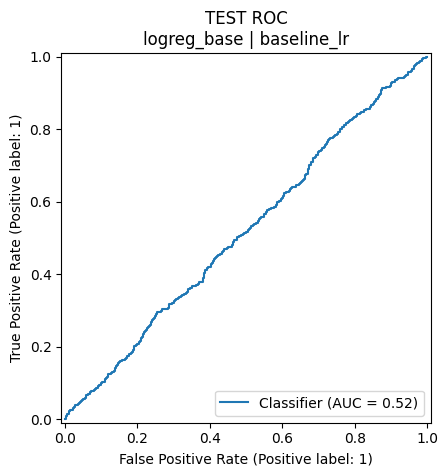

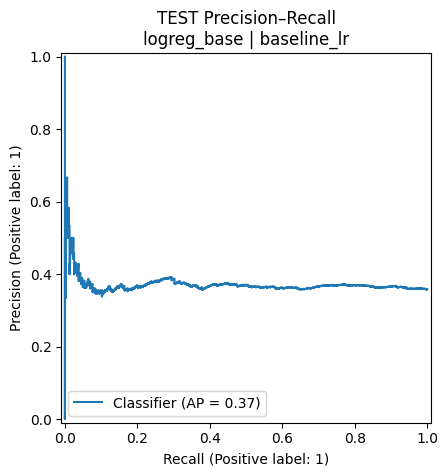

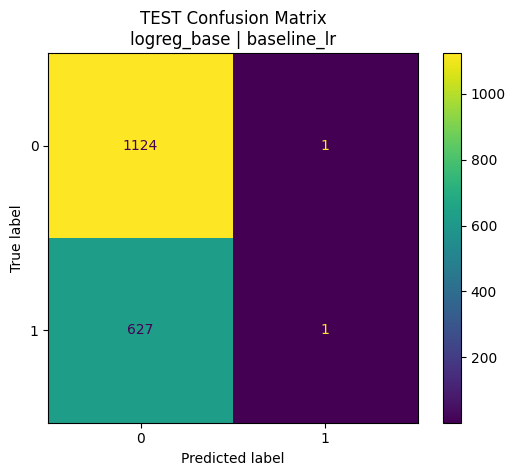

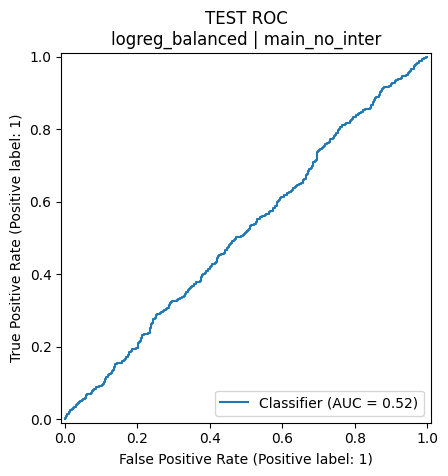

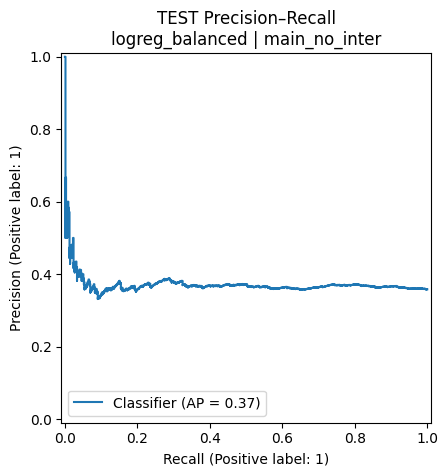

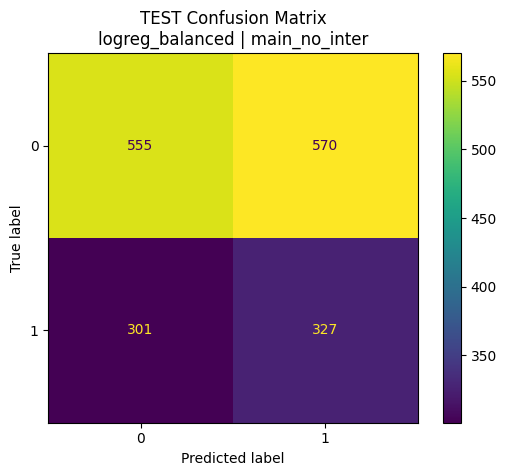

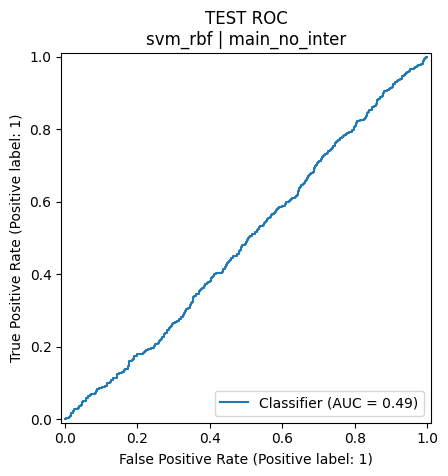

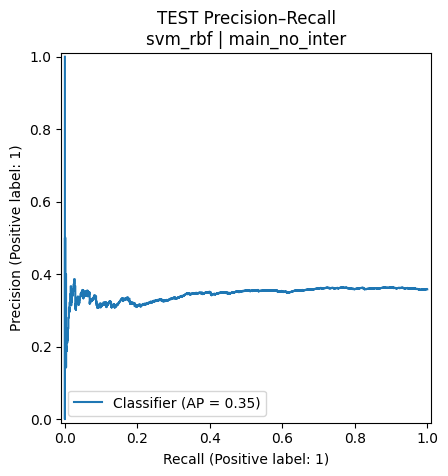

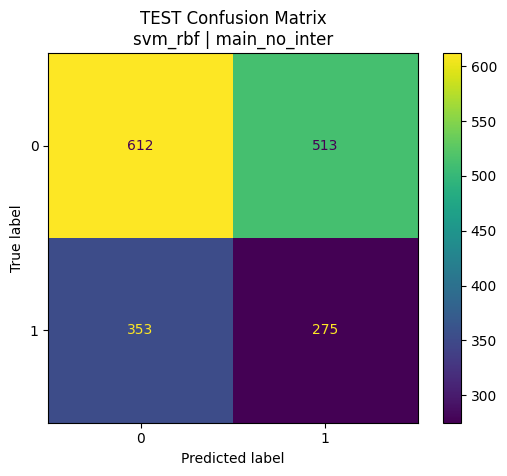

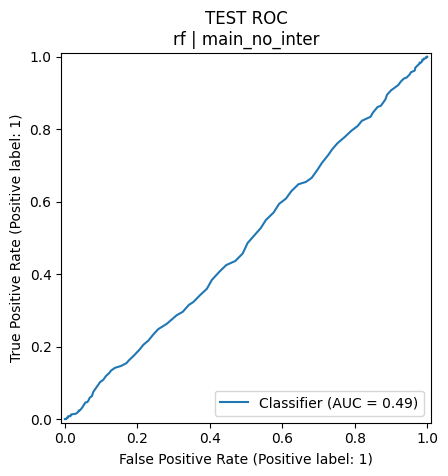

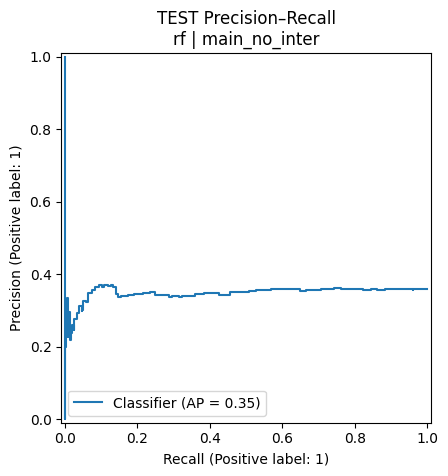

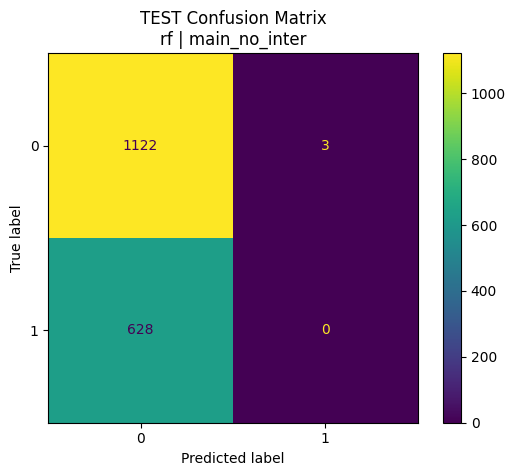

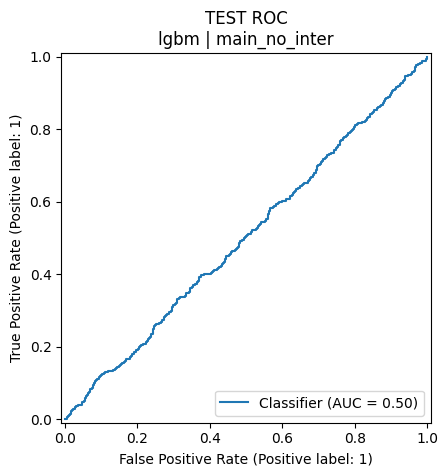

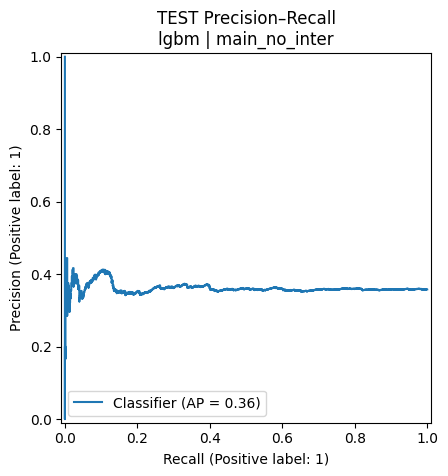

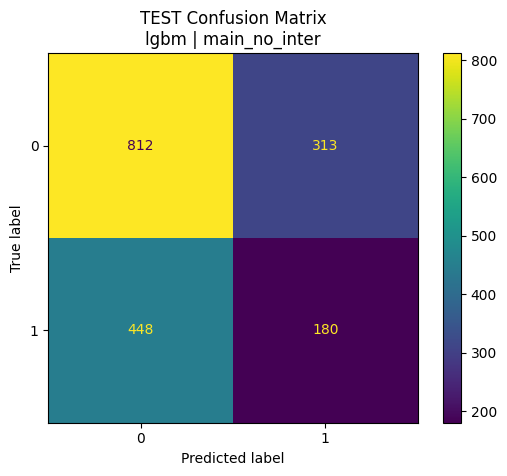

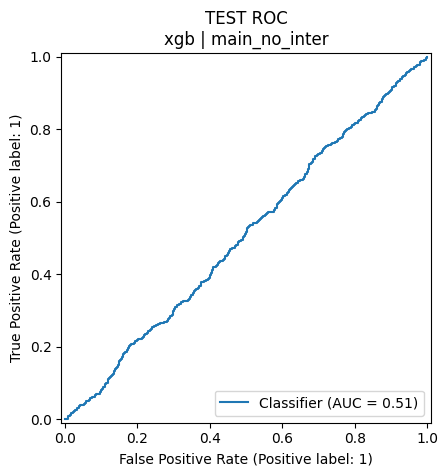

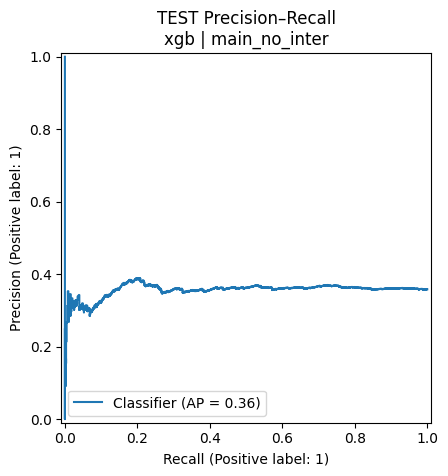

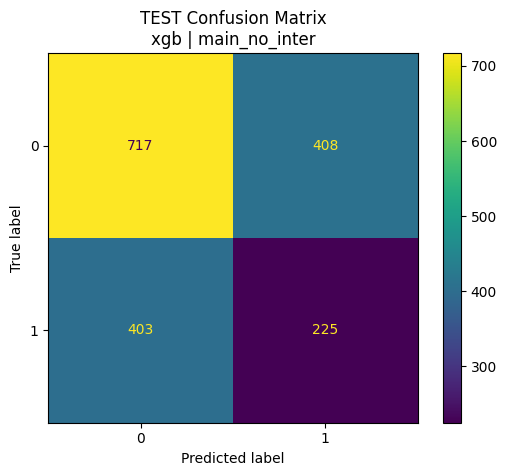

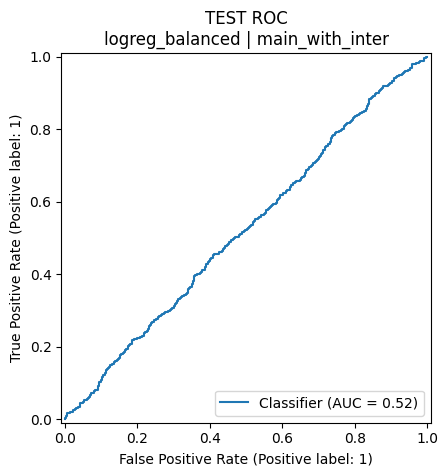

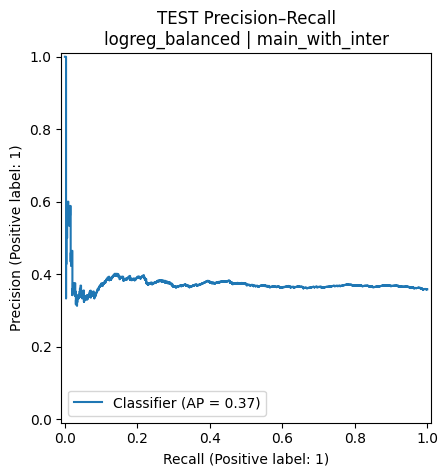

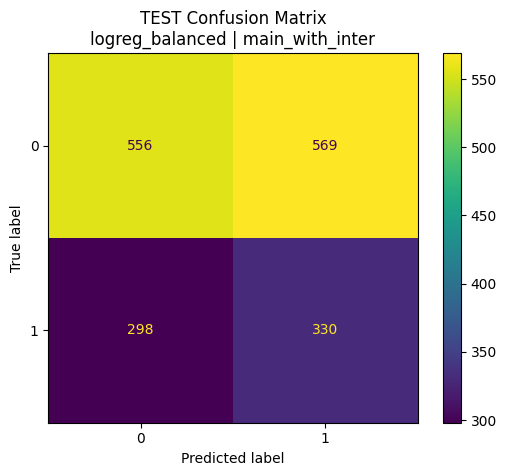

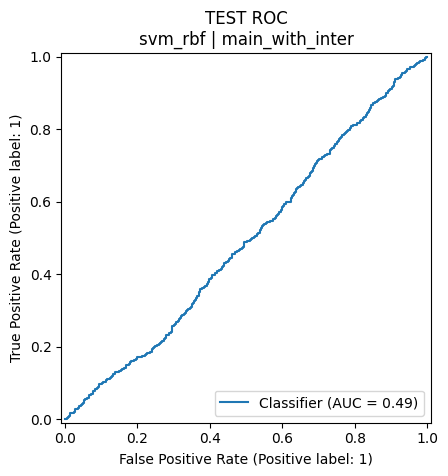

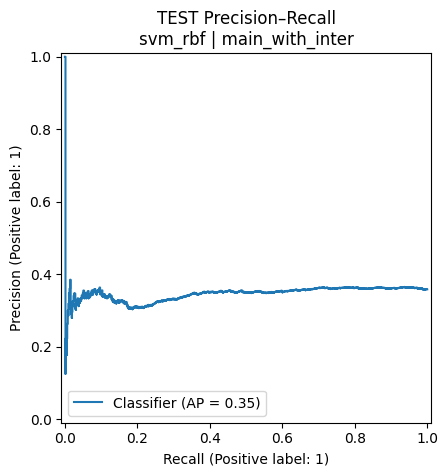

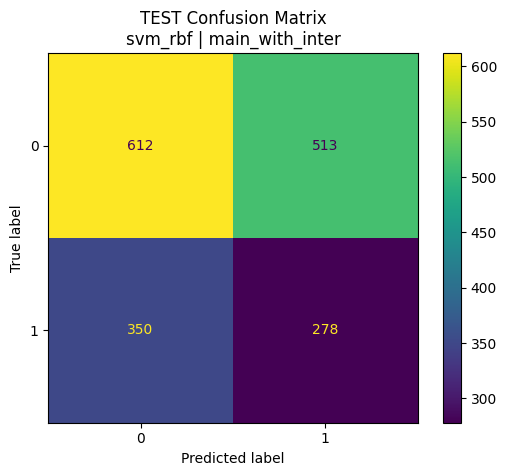

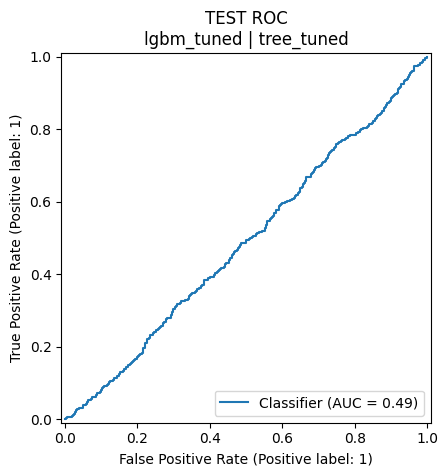

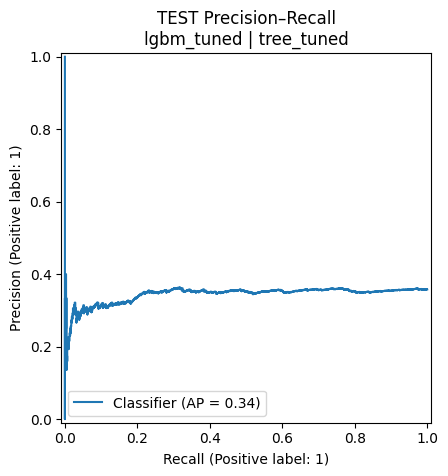

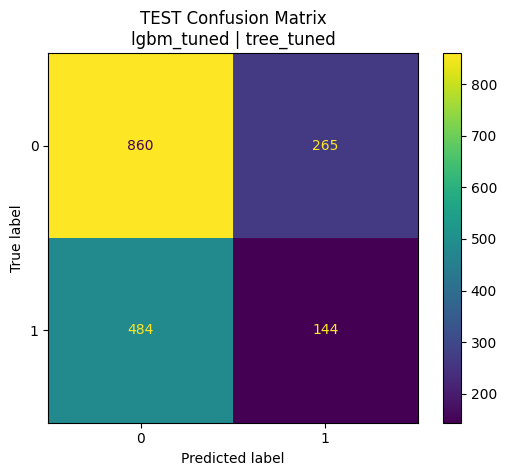

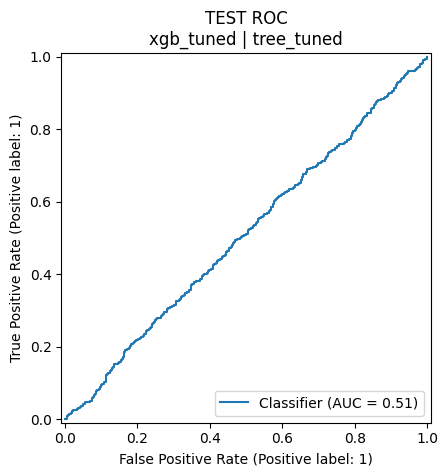

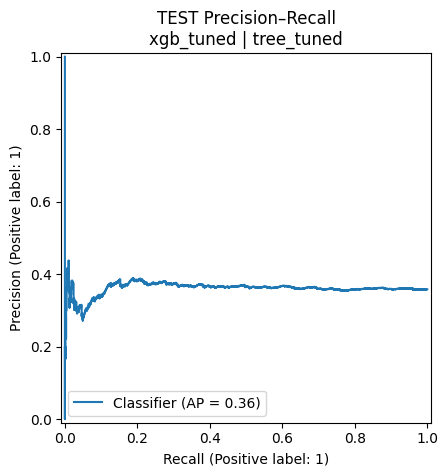

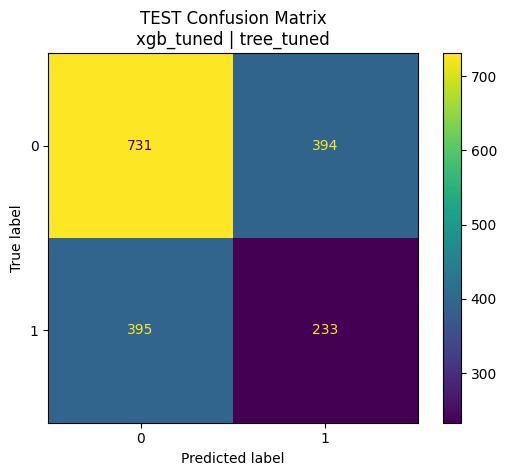

In [31]:
results = []

# List of (model_name, estimator) pairs.
model_grid = list(models.items())

# List of experiment configs (cfg_name, FactoryConfig, optional group tag)
experiments = [
    ("baseline_lr", cfg_baseline_lr, "stage1", ["logreg_base"]),

    ("main_no_inter", cfg_main_no_inter, "stage1", ["logreg_balanced", "svm_rbf", "rf", "lgbm", "xgb"]),
    ("main_with_inter", cfg_main_with_inter, "stage1", ["logreg_balanced", "svm_rbf"]),
]

experiments_stage2 = [
    ("tree_tuned", cfg_main_no_inter, "stage2", ["lgbm_tuned", "xgb_tuned"]),
]

all_experiments = experiments + experiments_stage2

import inspect
import pipeline.preprocessor as pp
import pipeline.pipeline_factory as pf

from pipeline.preprocessor import build_preprocessor
import inspect

[c for c in FS.ohe_cols if "country" in str(c).lower()]

[c for c in (FS.numeric_cols + FS.ordinal_cols + FS.binary_cols) if "country" in str(c).lower()]

print("country drop logic present?",
      "ohe_inputs = [c for c in ohe_inputs if c != \"country\"]" in inspect.getsource(build_preprocessor))


print("pp file:", pp.__file__)
print("pp.build_preprocessor line:", pp.build_preprocessor.__code__.co_firstlineno)

# If make_pipeline imports build_preprocessor into the factory module,
# check what function object the factory is pointing at:
if hasattr(pf, "build_preprocessor"):
    print("pf.build_preprocessor module:", pf.build_preprocessor.__module__)
    print("pf.build_preprocessor line:", pf.build_preprocessor.__code__.co_firstlineno)

# Show the first ~25 lines of the build_preprocessor being called
print("\n--- build_preprocessor source (first lines) ---")
src = inspect.getsource(pp.build_preprocessor).splitlines()
print("\n".join(src[:25]))

for cfg_name, cfg, group, model_names in all_experiments:
    for model_name in model_names:
        estimator = models[model_name]

        print(f"Running: {model_name} | cfg={cfg_name}")
        results.append(
            fit_and_log(
                model_name=model_name,
                estimator=estimator,
                cfg=cfg,
                cfg_name=cfg_name,
                group=group,
            )
        )


results_df = pd.DataFrame(results).sort_values(["roc_auc", "pr_auc"], ascending=False)
display(results_df)


Debug

'''# Using interactions?
print("n_interaction_cols:", len(FS.interaction_cols))
print("interaction_cols:", FS.interaction_cols)
'''

'''# MLFlow run ID dataframe

run_ids = [
    "76a44aede64343f0b952c97758489ba4",
    "af92a6f727684f1bae1fc055a8398153",
    "c4494f17182e491aae227b2ace5d07ef",
    "663101fd964648169fde35a637233012",
    "a06fe1a5241d43298f63be33f7af5030"
]

rows = []
for run_id in run_ids:
    run = mlflow.get_run(run_id)
    rows.append({
        "run_id": run_id,
        "run_name": run.data.tags.get("mlflow.runName"),
        **run.data.metrics,
        **run.data.params,
        **run.data.tags,
    })

df_runs = pd.DataFrame(rows)
df_runs'''

In [ ]:
# Filter MLflow runs by metric and tags
experiment_name = "CardioSentinel - Stage 1 - Baseline Model Comparison"
exp = mlflow.get_experiment_by_name(experiment_name)
assert exp is not None, f"Experiment not found: {experiment_name}"

# Filter: metric exists (not null) + optional stage filter
filter_string = "metrics.recall_at_precision_0p30 IS NOT NULL"
# Example: only stage2
# filter_string += " AND tags.stage = 'stage2'"

runs_df = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    output_format="pandas",
)

df_runs = (
    runs_df
    .dropna(subset=["metrics.recall_at_precision_0p30"])
    .sort_values("metrics.recall_at_precision_0p30", ascending=False)
)

df_runs



,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.test_precision,metrics.test_roc_auc,metrics.recall_at_precision_0p30,metrics.recall_at_precision_0p45,...,tags.project,tags.tuned,tags.cfg_name,tags.tuning_strategy,tags.model_type,tags.baseline,tags.precision_constraint,tags.interactions_linear,tags.interactions_tree,tags.experiment_group
0,2e8d7276c3b64bd38fb4bbbbe9ea1e56,277215230691325782,FINISHED,mlflow-artifacts:/277215230691325782/2e8d7276c...,2026-01-16 18:27:30.338000+00:00,2026-01-16 18:27:41.855000+00:00,0.371611,0.507933,1.000000,0.000000,...,CardioSentinel,true,tree_tuned,manual_grid,xgb,None,None,None,None,None
2,b6db254001f54c2e9d4c30b6bed853cd,277215230691325782,FINISHED,mlflow-artifacts:/277215230691325782/b6db25400...,2026-01-16 18:26:32.560000+00:00,2026-01-16 18:27:16.531000+00:00,0.351454,0.489686,1.000000,0.000000,...,CardioSentinel,false,main_with_inter,None,linear,None,None,None,None,None
3,27c6a704cb0d4cdd934d2e694820fb1e,277215230691325782,FINISHED,mlflow-artifacts:/277215230691325782/27c6a704c...,2026-01-16 18:26:24.273000+00:00,2026-01-16 18:26:32.336000+00:00,0.367075,0.521118,1.000000,0.003185,...,CardioSentinel,false,main_with_inter,None,linear,None,None,None,None,None
4,2e476cc890e34f9bb4d78b8a426ac83f,277215230691325782,FINISHED,mlflow-artifacts:/277215230691325782/2e476cc89...,2026-01-16 18:26:13.309000+00:00,2026-01-16 18:26:24.065000+00:00,0.355450,0.505863,1.000000,0.000000,...,CardioSentinel,false,main_no_inter,None,xgb,None,None,None,None,None
17,bcdd1ef1c1224cfc9a24c17e48fabf6f,277215230691325782,FINISHED,mlflow-artifacts:/277215230691325782/bcdd1ef1c...,2026-01-12 23:11:13.469000+00:00,2026-01-12 23:12:01.653000+00:00,0.348985,0.489520,1.000000,NaN,...,CardioSentinel,false,main_no_inter,None,linear,None,>=0.30,None,None,None
6,478b36891c7f4980b3d6e66293ed6f70,277215230691325782,FINISHED,mlflow-artifacts:/277215230691325782/478b36891...,2026-01-16 18:25:25.084000+00:00,2026-01-16 18:25:55.238000+00:00,0.000000,0.491118,1.000000,0.000000,...,CardioSentinel,false,main_no_inter,None,rf,None,None,None,None,None
7,f60b7d726960464a84a0d513d749b5bd,277215230691325782,FINISHED,mlflow-artifacts:/277215230691325782/f60b7d726...,2026-01-16 18:24:32.418000+00:00,2026-01-16 18:25:24.888000+00:00,0.348985,0.489520,1.000000,0.000000,...,CardioSentinel,false,main_no_inter,None,linear,None,None,None,None,None
8,47527426208a4b389803695698bd7559,277215230691325782,FINISHED,mlflow-artifacts:/277215230691325782/475274262...,2026-01-16 18:24:14.760000+00:00,2026-01-16 18:24:31.965000+00:00,0.364548,0.515748,1.000000,0.022293,...,CardioSentinel,false,main_no_inter,None,linear,None,None,None,None,None
9,b1488a03ed4f4922abb23e7da7047868,277215230691325782,FINISHED,mlflow-artifacts:/277215230691325782/b1488a03e...,2026-01-16 18:22:19.257000+00:00,2026-01-16 18:24:14.560000+00:00,0.500000,0.516640,1.000000,0.023885,...,CardioSentinel,false,baseline_lr,None,linear,true,None,None,None,None
18,2d9572893e5d4f4295bed04a581c154b,277215230691325782,FINISHED,mlflow-artifacts:/277215230691325782/2d9572893...,2026-01-12 23:11:04.917000+00:00,2026-01-12 23:11:13.318000+00:00,0.364548,0.515748,1.000000,NaN,...,CardioSentinel,false,main_no_inter,None,linear,None,>=0.30,None,None,None


In [36]:
# Filter MLflow runs by parameters and tags
experiment_name = "CardioSentinel - Stage 1 - Baseline Model Comparison"
exp = mlflow.get_experiment_by_name(experiment_name)
assert exp is not None, f"Experiment not found: {experiment_name}"

runs_df = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    #filter_string="tags.stage = 'stage2'",
    output_format="pandas",
)

df_runs = (
    runs_df
    .dropna(subset=["params.threshold_at_precision_0p30"])
    .sort_values("metrics.recall_at_precision_0p30", ascending=False)
)

df_runs


,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.test_precision,metrics.test_roc_auc,metrics.recall_at_precision_0p30,metrics.recall_at_precision_0p45,...,tags.project,tags.tuned,tags.cfg_name,tags.tuning_strategy,tags.model_type,tags.baseline,tags.precision_constraint,tags.interactions_linear,tags.interactions_tree,tags.experiment_group
0,2e8d7276c3b64bd38fb4bbbbe9ea1e56,277215230691325782,FINISHED,mlflow-artifacts:/277215230691325782/2e8d7276c...,2026-01-16 18:27:30.338000+00:00,2026-01-16 18:27:41.855000+00:00,0.371611,0.507933,1.000000,0.000000,...,CardioSentinel,true,tree_tuned,manual_grid,xgb,None,None,None,None,None
2,b6db254001f54c2e9d4c30b6bed853cd,277215230691325782,FINISHED,mlflow-artifacts:/277215230691325782/b6db25400...,2026-01-16 18:26:32.560000+00:00,2026-01-16 18:27:16.531000+00:00,0.351454,0.489686,1.000000,0.000000,...,CardioSentinel,false,main_with_inter,None,linear,None,None,None,None,None
8,47527426208a4b389803695698bd7559,277215230691325782,FINISHED,mlflow-artifacts:/277215230691325782/475274262...,2026-01-16 18:24:14.760000+00:00,2026-01-16 18:24:31.965000+00:00,0.364548,0.515748,1.000000,0.022293,...,CardioSentinel,false,main_no_inter,None,linear,None,None,None,None,None
3,27c6a704cb0d4cdd934d2e694820fb1e,277215230691325782,FINISHED,mlflow-artifacts:/277215230691325782/27c6a704c...,2026-01-16 18:26:24.273000+00:00,2026-01-16 18:26:32.336000+00:00,0.367075,0.521118,1.000000,0.003185,...,CardioSentinel,false,main_with_inter,None,linear,None,None,None,None,None
4,2e476cc890e34f9bb4d78b8a426ac83f,277215230691325782,FINISHED,mlflow-artifacts:/277215230691325782/2e476cc89...,2026-01-16 18:26:13.309000+00:00,2026-01-16 18:26:24.065000+00:00,0.355450,0.505863,1.000000,0.000000,...,CardioSentinel,false,main_no_inter,None,xgb,None,None,None,None,None
6,478b36891c7f4980b3d6e66293ed6f70,277215230691325782,FINISHED,mlflow-artifacts:/277215230691325782/478b36891...,2026-01-16 18:25:25.084000+00:00,2026-01-16 18:25:55.238000+00:00,0.000000,0.491118,1.000000,0.000000,...,CardioSentinel,false,main_no_inter,None,rf,None,None,None,None,None
9,b1488a03ed4f4922abb23e7da7047868,277215230691325782,FINISHED,mlflow-artifacts:/277215230691325782/b1488a03e...,2026-01-16 18:22:19.257000+00:00,2026-01-16 18:24:14.560000+00:00,0.500000,0.516640,1.000000,0.023885,...,CardioSentinel,false,baseline_lr,None,linear,true,None,None,None,None
7,f60b7d726960464a84a0d513d749b5bd,277215230691325782,FINISHED,mlflow-artifacts:/277215230691325782/f60b7d726...,2026-01-16 18:24:32.418000+00:00,2026-01-16 18:25:24.888000+00:00,0.348985,0.489520,1.000000,0.000000,...,CardioSentinel,false,main_no_inter,None,linear,None,None,None,None,None
5,c3b162c035f647e5ace1c61c417469f7,277215230691325782,FINISHED,mlflow-artifacts:/277215230691325782/c3b162c03...,2026-01-16 18:25:55.403000+00:00,2026-01-16 18:26:13.095000+00:00,0.365112,0.500856,0.990446,0.000000,...,CardioSentinel,false,main_no_inter,None,lgbm,None,None,None,None,None
1,756e47aab70b4ebf90f0870bc1e592b1,277215230691325782,FINISHED,mlflow-artifacts:/277215230691325782/756e47aab...,2026-01-16 18:27:16.719000+00:00,2026-01-16 18:27:30.095000+00:00,0.352078,0.487424,0.958599,0.000000,...,CardioSentinel,true,tree_tuned,manual_grid,lgbm,None,None,None,None,None


In [37]:
df_runs.to_csv("model_runs_summary.csv")